# Capstone 2:  
### EmproiUm Sales Territory Analysis

This project analyzes in‑store sales performance for EmporiUm, focusing on the two assigned Northeast sales territories: Massachusetts (managed by Bo Heap) and New Jersey (managed by Miami Vue). The analysis explores monthly revenue trends, store performance rankings, top customers, product category behavior, and key opportunities to guide next‑quarter marketing strategy.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
store_sales = pd.read_csv("StoreSales.csv")
store_sales.info()
store_sales.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [4]:
store_detail = pd.read_csv("StoreDetail.csv")
store_detail.info()
store_detail.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [5]:
products = pd.read_csv("Products.csv")
products.info()
products.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [6]:
product_categories = pd.read_csv("ProductCategories.csv")
product_categories.info()
product_categories.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [7]:
customer_list = pd.read_csv("customer_list.csv", sep='|')
customer_list.info()
customer_list.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


## Core Marketing Analysis

### **Massachusetts vs New Jersey**
###### Who are the territory managers for the sales territories assigned? What are the store IDs and cities for the stores in each assigned sales territory?  
**Assigned Territory:** Massachusetts (within NE Region)  
**Territory Manager:** Bo Heap  
Manages 18 Stores in the State of Massachusets

**Comparison Territory:** New Jersey  
**Territory Manager:** Miami Vue  
Manages 16 Stores in the State of New Jersey  

In [8]:
mass_nj = store_detail [(store_detail ['State'] == 'Massachusetts') | (store_detail ['State'] == 'New Jersey')]
mass_nj [['Store ID', 'Store Location', 'State', 'Territory Manager']]

,Store ID,Store Location,State,Territory Manager
52,730,Boston,Massachusetts,Bo Heap
53,801,Attleboro,Massachusetts,Bo Heap
54,802,Falmouth,Massachusetts,Bo Heap
55,803,Framingham,Massachusetts,Bo Heap
56,804,Haverhill,Massachusetts,Bo Heap
57,805,Hingham,Massachusetts,Bo Heap
58,806,Holyoke,Massachusetts,Bo Heap
59,807,Leominster,Massachusetts,Bo Heap
60,808,Lowell,Massachusetts,Bo Heap
61,809,Lynn,Massachusetts,Bo Heap


# Total Revenue 
###### What is monthly total revenue for in-store sales in each of the two sales territories, over the full period covered by the data?

*(In-Store Sales)*  
**Date Range:** 1/1/2022 to 12/31/2025  

**Massachusetts:** $5,733,256.27  
**New Jersey:** $5,175,405.87

In [13]:
sales_detail = pd.merge(
    store_sales,
    store_detail,
    on='Store ID',
    how='left')

sales_detail['Transaction Date'] = pd.to_datetime(sales_detail['Transaction Date'])

states = ['Massachusetts', 'New Jersey']
filtered = sales_detail[sales_detail['State'].isin(states)]

filtered['Month'] = filtered['Transaction Date'].dt.to_period('M')

monthly_revenue = (
    filtered
        .groupby(['State', 'Month'])['Sale Amount']
        .sum()
        .reset_index())

In [11]:
df_pivot = monthly_revenue.pivot(index="Month", columns="State", values="Sale Amount")
df_pivot

State,Massachusetts,New Jersey
Month,,
2022-01,69396.42,70597.51
2022-02,65616.00,63225.69
2022-03,77390.00,64779.71
2022-04,81333.60,78465.40
2022-05,75919.64,73037.02
2022-06,81227.82,66868.55
2022-07,67271.23,72096.47
2022-08,73543.48,73904.91
2022-09,58716.74,77869.16


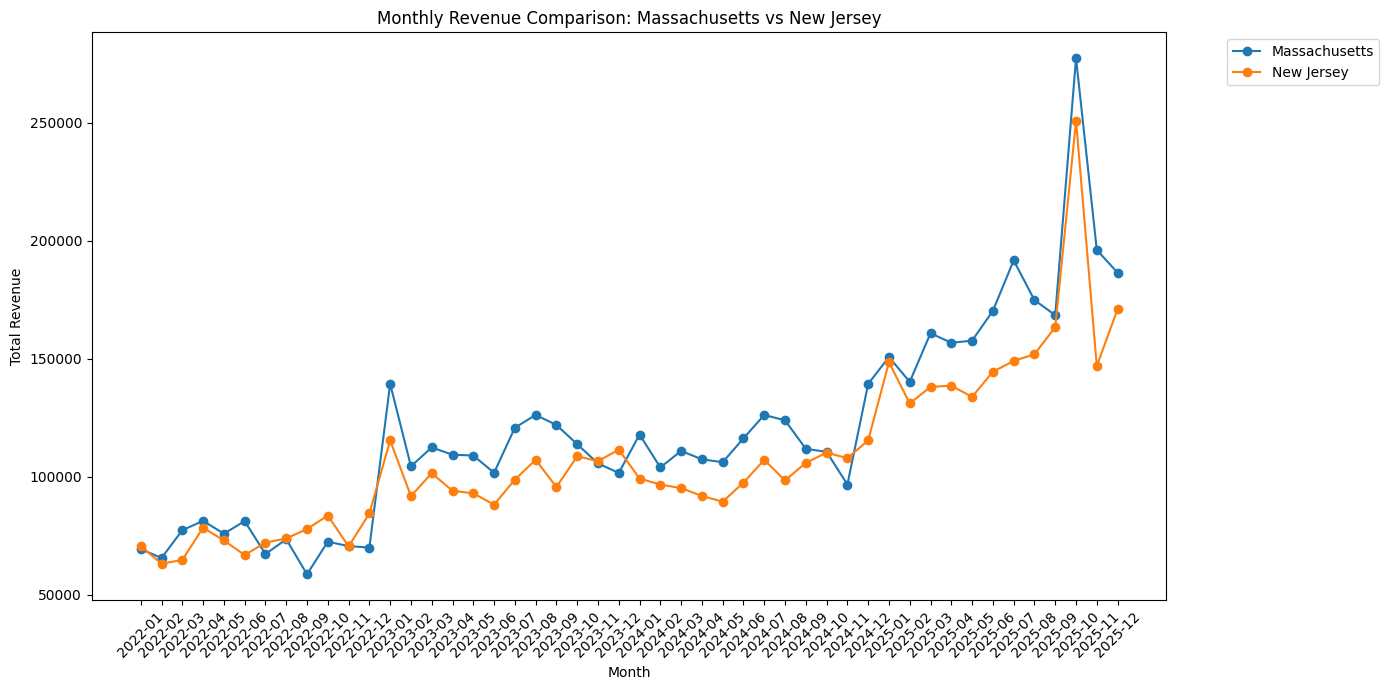

In [14]:
plt.figure(figsize=(14,7))

for col in df_pivot.columns:
    plt.plot(df_pivot.index.astype(str), df_pivot[col], marker='o', label=col)

plt.title("Monthly Revenue Comparison: Massachusetts vs New Jersey")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [27]:
sales_detail = pd.merge(
    store_sales,
    store_detail,
    on='Store ID')

mass_nj_total_sales = ['Massachusetts', 'New Jersey']
sales_detail = (sales_detail[sales_detail['State'].isin(mass_nj_total_sales)]
    .groupby('State', as_index=False)['Sale Amount'].sum()) 

sales_detail

,State,Sale Amount
0,Massachusetts,5733256.27
1,New Jersey,5175405.87


## Sales Performance  
###### How would you rank the sales performance of each store in each sales territory? Which are the top-performing stores?

**Massachusetts (Top Performing Stores):**
1. Worcester (Store 817) - $602,183
2. Leominster (Store 807) - $338,009
3. Nantucket (Store 810) - $335,548
4. Provincetown (Store 814) - $328,861
5. Northampton (Store 812) - $322,039

**New Jersey (Top Performing Stores):**
1. Newark (Store 835) - $623,163
2. Trenton (Store 838) - $597,566
3. Hoboken (Store 830) - $316,775
4. Atlantic City (Store 824) - $314,514
5. New Brunswick (Store 834) - $311,056

In [28]:
sales_detail = pd.merge(
    store_sales,
    store_detail,
    on='Store ID')

mas_nj = ['Massachusetts', 'New Jersey']

store_rank = (sales_detail[sales_detail['State'].isin(mas_nj)]
        .groupby(['State', 'Store ID'], as_index=False)['Sale Amount']
        .sum()
        .sort_values(['State', 'Sale Amount'], ascending=[True, False])
        .groupby('State')
        .head(5)
        .reset_index())
store_rank['Rank'] = store_rank.groupby('State').cumcount()+1

store_rank = pd.merge(
    store_rank,
    store_detail[['Store ID', 'Store Location']],
    on='Store ID',
    how='left')
store_rank

,index,State,Store ID,Sale Amount,Rank,Store Location
0,17,Massachusetts,817,602183.44,1,Worcester
1,7,Massachusetts,807,338009.10,2,Leominster
2,10,Massachusetts,810,335547.81,3,Nantucket
3,14,Massachusetts,814,328860.51,4,Provincetown
4,12,Massachusetts,812,322039.24,5,Northampton
5,29,New Jersey,835,623163.53,1,Newark
6,32,New Jersey,838,597565.68,2,Trenton
7,24,New Jersey,830,316775.48,3,Hoboken
8,18,New Jersey,824,314513.77,4,Atlantic City
9,28,New Jersey,834,311056.42,5,New Brunswick


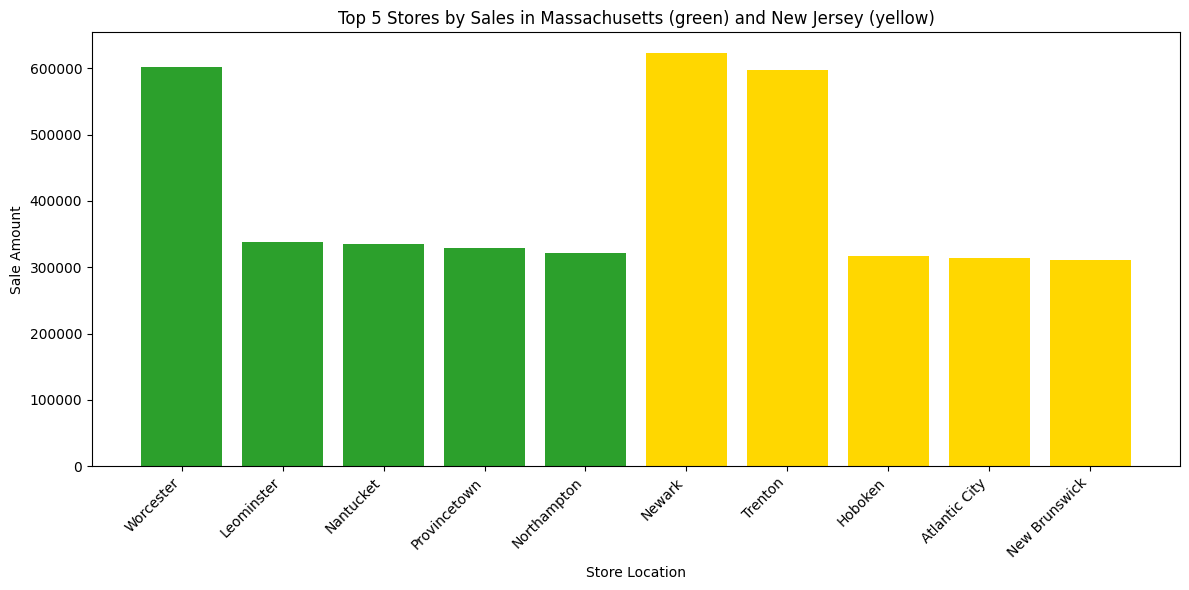

In [50]:

store_rank_sorted = store_rank.sort_values(['State', 'Sale Amount'], ascending=[True, False])

plt.figure(figsize=(12,6))

plt.bar(store_rank_sorted['Store Location'], store_rank_sorted['Sale Amount'],
        color=['tab:green' if state=='Massachusetts' else 'gold' 
               for state in store_rank_sorted['State']])

plt.xlabel('Store Location')
plt.ylabel('Sale Amount')
plt.title('Top 5 Stores by Sales in Massachusetts (green) and New Jersey (yellow)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Top Customers  
###### Comparing the customer ID from the customer list data with the rewards ID from the sales data, who were the top customers in each sales territory?

**Massachusetts (Top Customers):**  
1. Beverly Crusher - $4,758.92
2. Tracy Jordan - $4,197.55
3. Stanley H. - $3,979.73
4. Monica Geller - $3,966.91
5. Mellie Grant - $3,948.41
6. Julian Bashir - $3,883.60
7. Mike E. - $3,788.67
8. Kaylee Frye - $3,725.87
9. Nate Jacobs - $3,569.36
10. Pamela James - $3,523.01

**New Jersey (Top Customers):**  
1. Ben Linus - $4,810.66
2. Kim Wexler - $4,215.58
3. Nicky Nichols - $4,164.21
4. Bart - $3,862.61
5. Lieutenant Duffy - $3,859.16
6. Stan Z. - $3,818.64
7. Arthur Fonzarelli - $3,610.03
8. Lucas - $3,484.89
9. Helen M. - $3,469.23
10. Teddy - $3,452.43


In [31]:
customer_list = pd.read_csv("customer_list.csv", sep="|")

customer_list.rename(columns={"cust_id": "CustomerID"}, inplace=True)
store_sales.rename(columns={"RewardsID": "CustomerID"}, inplace=True)

In [32]:
sales_with_store = pd.merge(
    store_sales,
    store_detail,
    on="Store ID",
    how="left")

In [33]:
sales_full = pd.merge(
    sales_with_store,
    customer_list,
    on="CustomerID",
    how="left")

In [34]:
mass_nj = ['Massachusetts', 'New Jersey']

customer_sales = (
    sales_full
        .groupby(["Region", "State", "CustomerID", "name"], as_index=False)["Sale Amount"]
        .sum())

customer_sales_NE = customer_sales[customer_sales["State"].isin(mass_nj)]

customer_sales_NE["Rank"] = (
    customer_sales_NE
        .groupby("State")["Sale Amount"]
        .rank(method="dense", ascending=False))

top_customers_mass_nj = (
    customer_sales_NE
        .query("Rank <= 10")
        .sort_values(["State", "Sale Amount"], ascending=[True, False]))

top_customers_mass_nj

,Region,State,CustomerID,name,Sale Amount,Rank
2313,Northeast,Massachusetts,292.0,Beverly Crusher,4758.92,1.0
2405,Northeast,Massachusetts,384.0,Tracy Jordan,4197.55,2.0
2068,Northeast,Massachusetts,47.0,Stanley H.,3979.73,3.0
2024,Northeast,Massachusetts,3.0,Monica Geller,3966.91,4.0
2209,Northeast,Massachusetts,188.0,Mellie Grant,3948.41,5.0
2321,Northeast,Massachusetts,300.0,Julian Bashir,3883.60,6.0
2038,Northeast,Massachusetts,17.0,Mike E.,3788.67,7.0
2337,Northeast,Massachusetts,316.0,Kaylee Frye,3725.87,8.0
2365,Northeast,Massachusetts,344.0,Nate Jacobs,3569.36,9.0
2199,Northeast,Massachusetts,178.0,Pamela James,3523.01,10.0


# Category‑Level Monthly Sales Trends and Opportunities for Growth  
*What is the number of transactions per month by product category in each assigned territory? What is total sales revenue per month by category?*  

-Technology & Accessories and Stationery & Supplies consistently show the highest monthly transaction counts in both Massachusetts and New Jersey for months leading up to the end of the year or mid year. 

**Massachusetts peaks:**
466 transactions (Stationery & Supplies, Apr 2025)  
455 transactions (Technology & Accessories, Oct 2025)
*Top Revenue:* $213,921 (October 2025)

**New Jersey peaks:**
422 transactions (Technology & Accessories, Oct 2025)  
413 transactions (Stationery & Supplies, Jun 2025)
*Top Revenue:* $192,758 (October 2025)


*What might this tell you about the most popular products, and where could there be opportunity for growth?*  

**Most popular category:** Technology & Accessories  
**High-demand** (but lower revenue): Stationary & Supplies  
**Growth Opportunities:**  
-Expand tech inventory and promotions  
-Increase margins on stationery through bundles or premium items  
-Reevaluate lower‑performing categories like Books and Art Supplies


In [15]:
sales_with_store = pd.merge(
    store_sales,
    store_detail,
    on="Store ID",
    how="left")

sales_with_products = pd.merge(
    sales_with_store,
    products,
    on="Prod Num",
    how="left")

sales_full = pd.merge(
    sales_with_products,
    product_categories,
    on="SubcategoryID",
    how="left")

sales_full.rename(columns={"Transaction Date": "Date"}, inplace=True)

sales_full["Date"] = pd.to_datetime(sales_full["Date"])
sales_full["Month"] = sales_full["Date"].dt.to_period("M")

transactions_per_month = (
    sales_full
        .groupby(["Region", "State", "Month", "Category"])
        .size()
        .reset_index(name="Transaction Count"))

revenue_per_month = (
    sales_full
        .groupby(["Region", "State", "Month", "Category"])["Sale Amount"]
        .sum()
        .reset_index(name="Total Revenue"))

monthly_category_summary = pd.merge(
    transactions_per_month,
    revenue_per_month,
    on=["Region", "State", "Month", "Category"])

mass_nj = ['Massachusetts', 'New Jersey']

monthly_category_mass_nj = monthly_category_summary[
    monthly_category_summary["State"].isin(mass_nj)]

monthly_category_mass_nj

,Region,State,Month,Category,Transaction Count,Total Revenue
1152,Northeast,Massachusetts,2022-01,Apparel and Merchandise,83,3008.15
1153,Northeast,Massachusetts,2022-01,Art Supplies,111,3464.11
1154,Northeast,Massachusetts,2022-01,Books (General),41,1062.65
1155,Northeast,Massachusetts,2022-01,Stationery and Supplies,111,1283.57
1156,Northeast,Massachusetts,2022-01,Technology & Accessories,112,48949.88
...,...,...,...,...,...,...
1723,Northeast,New Jersey,2025-12,Art Supplies,220,7403.37
1724,Northeast,New Jersey,2025-12,Books (General),78,1932.69
1725,Northeast,New Jersey,2025-12,Stationery and Supplies,242,2829.86
1726,Northeast,New Jersey,2025-12,Technology & Accessories,281,131024.14


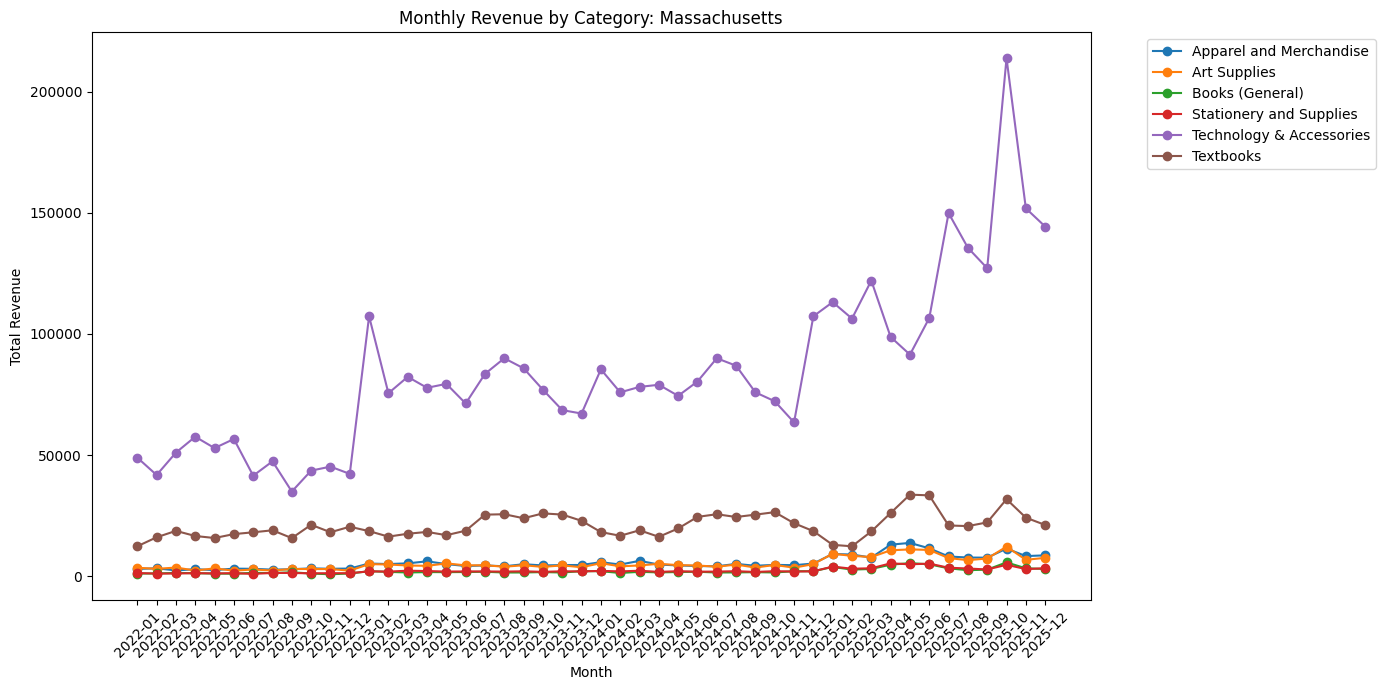

In [42]:
state = "Massachusetts"
df_state = monthly_category_mass_nj[monthly_category_mass_nj["State"] == state]
df_pivot = df_state.pivot(index="Month", columns="Category", values="Total Revenue")

plt.figure(figsize=(14,7))
for col in df_pivot.columns:
    plt.plot(df_pivot.index.astype(str), df_pivot[col], marker='o', label=col)

plt.title(f"Monthly Revenue by Category: {state}")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

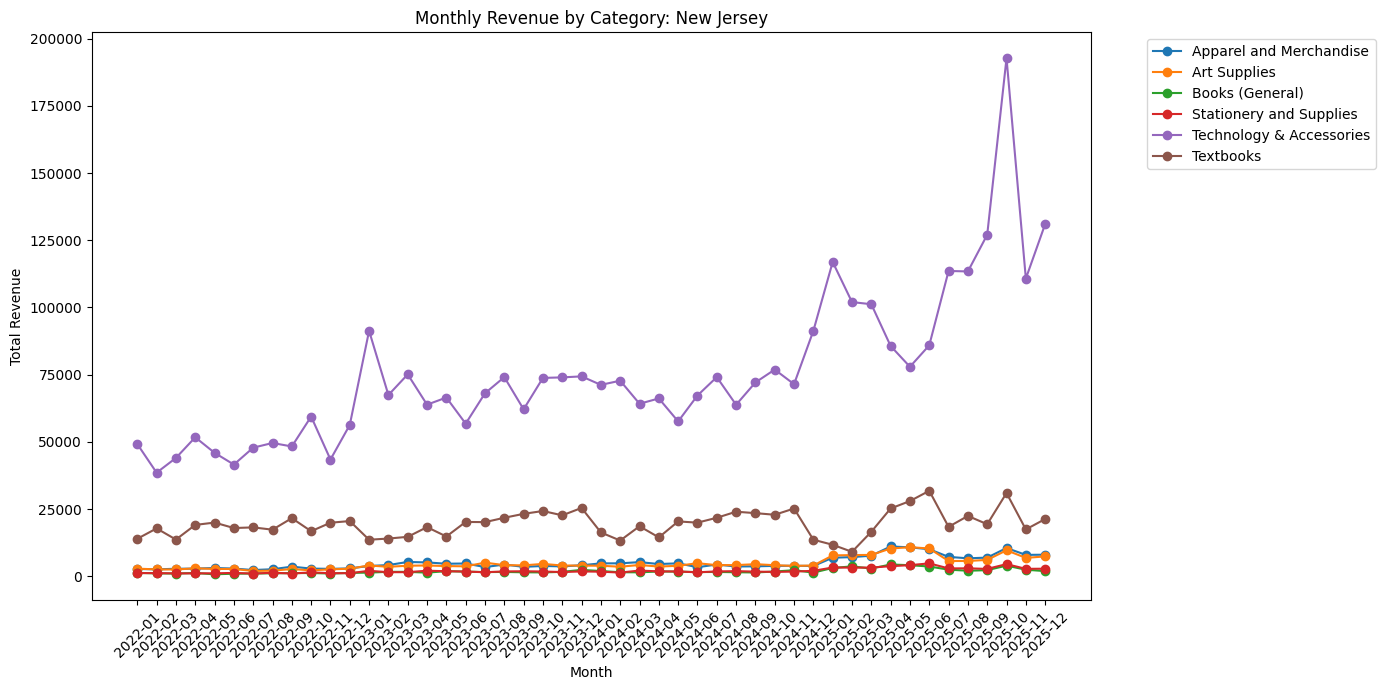

In [43]:
state = "New Jersey"
df_state = monthly_category_mass_nj[monthly_category_mass_nj["State"] == state]
df_pivot = df_state.pivot(index="Month", columns="Category", values="Total Revenue")

plt.figure(figsize=(14,7))
for col in df_pivot.columns:
    plt.plot(df_pivot.index.astype(str), df_pivot[col], marker='o', label=col)

plt.title(f"Monthly Revenue by Category: {state}")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(14,7))
for col in df_pivot.columns:
    plt.plot(df_pivot.index.astype(str), df_pivot[col], marker='o', label=col)

plt.title(f"Monthly Revenue by Category: {state}")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [37]:
top5_transactions = (
    monthly_category_mass_nj
        .sort_values(["State", "Transaction Count"], ascending=[True, False])
        .groupby("State")
        .head(5))

top5_transactions

,Region,State,Month,Category,Transaction Count,Total Revenue
1389,Northeast,Massachusetts,2025-04,Stationery and Supplies,466,5284.46
1426,Northeast,Massachusetts,2025-10,Technology & Accessories,455,213921.34
1401,Northeast,Massachusetts,2025-06,Stationery and Supplies,452,5166.24
1395,Northeast,Massachusetts,2025-05,Stationery and Supplies,443,4893.61
1386,Northeast,Massachusetts,2025-04,Apparel and Merchandise,427,12999.41
1714,Northeast,New Jersey,2025-10,Technology & Accessories,422,192758.68
1689,Northeast,New Jersey,2025-06,Stationery and Supplies,413,4810.37
1713,Northeast,New Jersey,2025-10,Stationery and Supplies,398,4535.02
1683,Northeast,New Jersey,2025-05,Stationery and Supplies,385,4150.50
1677,Northeast,New Jersey,2025-04,Stationery and Supplies,365,3764.08


In [38]:
top5_transactions = (
    monthly_category_mass_nj
        .sort_values(["State", "Total Revenue"], ascending=[True, False])
        .groupby("State")
        .head(5))

top5_transactions

,Region,State,Month,Category,Transaction Count,Total Revenue
1426,Northeast,Massachusetts,2025-10,Technology & Accessories,455,213921.34
1432,Northeast,Massachusetts,2025-11,Technology & Accessories,296,151890.30
1408,Northeast,Massachusetts,2025-07,Technology & Accessories,268,149927.28
1438,Northeast,Massachusetts,2025-12,Technology & Accessories,293,144387.39
1414,Northeast,Massachusetts,2025-08,Technology & Accessories,295,135601.15
1714,Northeast,New Jersey,2025-10,Technology & Accessories,422,192758.68
1726,Northeast,New Jersey,2025-12,Technology & Accessories,281,131024.14
1708,Northeast,New Jersey,2025-09,Technology & Accessories,238,127062.89
1660,Northeast,New Jersey,2025-01,Technology & Accessories,228,116927.74
1696,Northeast,New Jersey,2025-07,Technology & Accessories,217,113591.87


# Marketing Recommendation 
What is your recommendation for where to focus marketing attention in the next quarter?

### Prioritize Technology & Accessories
Both states thrived in **Technology & Accesories** sales as it's top selling category  
**Massachusetts’ top month:**  
Technology & Accessories - 455 transactions ($213,921.34)  
**New Jersey’s top month:**  
Technology & Accessories - 422 transactions ($192,758.68)

### Target High‑Performing Stores for Local Promotions
**Massachusetts:**
1. Worcester - $602,183.44  
2. Leominster - $338,009.10  
3. Nantucket - $335,547.81  

**New Jersey:**
1. Newark - $623,163.53
2. Trenton - $597,565.68
3. Hoboken - $316,775.48

### Start Loyalty Rewards?
**Massachusetts:**
1. Beverly Crusher - $4,758.92
2. Tracy Jordan - $4,197.55

**New Jersey:**
1. Ben Linus - $4,810.66
2. Kim Wexler - $4,215.58

### Promote low selling products during peak months
**Massachusetts:** 10/2025 - $277,382.19
**New Jersey:** 10/2025 - $250,830.46

It would be beneficial to promote overlooked products during busy seasons (Q4 and Q1) to capitalize on high foot‑traffic periods and boost underperforming categories and products.